In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from shapely import wkb
import textwrap

from src.text_processing_functions import *
from src.data_format import format_output
from src.geocoding_utils import get_continent
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.impact_def import *
from src.ImpactRegistry import Impacts
from src.impact_def import IMPACT_SUBTYPE_MERGER, IMPACT_SUBTYPES_MERGED

path_save_fig = DATA_FIGURE / "data_overview"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
res_name_llm = "filter_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v231225"

##### If import csv file
df_llm_all_geo = pd.read_csv(DATA_OUT_PROC / (res_name_llm+'.csv'))
df_llm_all_geo = format_output(df_llm_all_geo)

##### If import parquet file

# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC / (res_name_llm+'.parquet'))
# df_llm_all_geo["geometry"] = df_llm_all_geo["geometry"].apply(wkb.loads)
# df_llm_all_geo = gpd.GeoDataFrame(
#     df_llm_all_geo,
#     geometry="geometry",
#     crs="EPSG:4326" 
# )

In [4]:
len(df_llm_all_geo)

11512

In [5]:
df_llm_all_geo.locationLowestAdmin.value_counts()

locationLowestAdmin
ADM_0    6237
ADM_1    4168
ADM_2    1106
Name: count, dtype: int64

In [6]:
# Import 
world = gpd.read_file(ADMIN_PATH / "ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

In [7]:
continent_offsets = {
    'Africa': (0, -0.20),
    'Asia': (0.15, -0.05),
    'Europe': (-0.15, -0.02),
    'Oceania' : (0.08, 0.02),
    'North America' : (-0.05, -0.15),
    'South America' : (-0.05, -0.02)
}

In [12]:
len(df_llm_all_geo)

11512

In [13]:
# Look for global statistics
print("Number of countries with recorded impact", df_llm_all_geo.explode("country_iso3").country_iso3.nunique())
print("Number of impactSubtypes", df_llm_all_geo.impactSubtype.nunique())
print("Number of unique appeal/hazards", len(df_llm_all_geo.explode("hazards").groupby(["appealCode", "hazards"])))

Number of countries with recorded impact 145
Number of impactSubtypes 20
Number of unique appeal/hazards 1861


# Hazard Map

In [6]:
hazard_colormap = {
    # 🔥 Environmental & Climatic
    'Drought': '#C2B280',                # sandy beige — dry/arid land
    'Wildfire': '#D1495B',               # strong red — fire and danger
    'Extreme warm temperature': '#E26D5A',# coral/orange — heat
    'Extreme cold temperature': '#A6CEE3',# icy blue — cold

    # 🌋 Geophysical
    'Earthquake': '#7F7F7F',             # neutral gray — ground rupture
    'Mass movement': '#8C564B',          # earthy brown — landslides
    'Volcanic activity': '#E17C05',      # lava orange — volcanic tones

    # 🌊 Hydrological / Meteorological
    'Flood': '#1F77B4',                  # deep blue — water/flood
    'Wave action': '#17BECF',            # cyan — ocean/wave
    'Tropical storm': '#2CA02C',         # green — tropical vegetation/storm
    'Convective storm': '#5B8E7D',       # teal — thunderstorm tone
    'Other storm': '#BCBD22',            # olive — extratropical/windstorm

    # ☣️ Biological / Social
    'Epidemic': '#E377C2',               # magenta — biological hazard
    'Conflict': '#7F3121'                # dark red-brown — violence/unrest
}

hazard_order = list(hazard_colormap.keys())

In [8]:
all_reports_grp = df_llm_all_geo.explode('country_iso3').groupby('appealCode').agg(iso_code = ("country_iso3", "first")).reset_index()
all_reports_country_count = all_reports_grp.groupby("iso_code").agg(appeal_count = ("appealCode", "nunique"))
world_2 = world.merge(all_reports_country_count, how="left", left_on="ISO_A3", right_on="iso_code")

In [9]:
# df_llm_all_geo['continent'] = df_llm_all_geo['country_iso3'].apply(
#     lambda iso_list: list({get_continent(iso, world_2) for iso in iso_list if iso}) 
#     if isinstance(iso_list, list) else None
# )

# df_llm_all_geo["continent"] = df_llm_all_geo["country_iso3"].apply(
#         lambda iso_list: sorted(
#             {iso_to_continent.get(iso) for iso in iso_list if iso in iso_to_continent}
#         ) if isinstance(iso_list, list) else []
#     )

# Filter out rows without continent
valid_continents = df_llm_all_geo.dropna(subset=['continent'])
df = valid_continents.explode('continent').explode('hazards')
df = df.dropna(subset=['continent', 'hazards'])
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_30084\4184518070.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


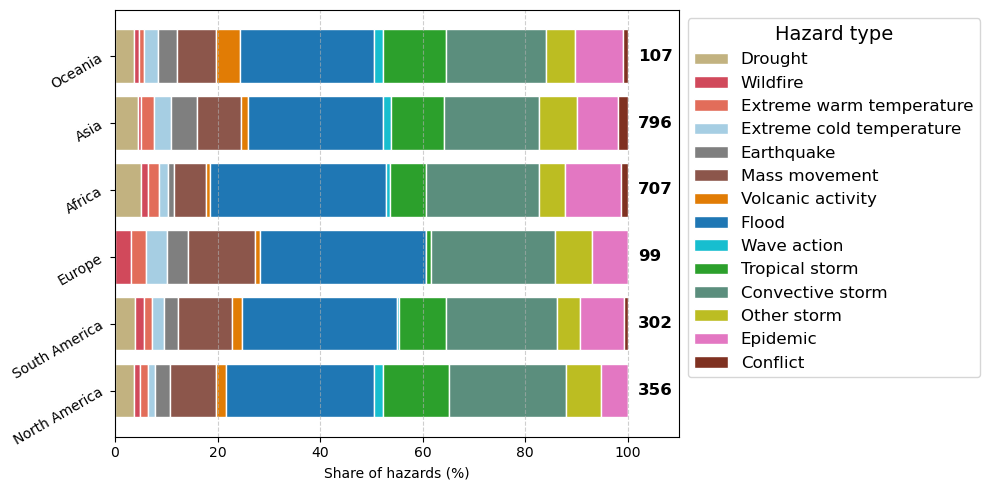

In [11]:
continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia',  'Oceania']

# Ensure the columns follow the order of hazard_colormap
# hazard_order = [h for h in hazard_colormap.keys() if h in hazard_counts.columns]
hazard_counts = hazard_counts.loc[continent_order]
hazard_counts = hazard_counts[hazard_order]

# Convert to percentage per continent
hazard_counts_percent = hazard_counts.div(hazard_counts.sum(axis=1), axis=0) * 100
hazard_counts_total = hazard_counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

left = [0] * len(hazard_counts)
for hazard in hazard_counts.columns:
    ax.barh(
        hazard_counts.index,
        hazard_counts_percent[hazard],
        left=left,
        color=hazard_colormap.get(hazard, 'gray'),
        edgecolor='white',
        label=hazard
    )
    left += hazard_counts_percent[hazard].values

# Add total counts at end of each bar
for i, total in enumerate(hazard_counts_total):
    ax.text(102, i, f'{total}', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(0, 110)
ax.set_xlabel('Share of hazards (%)')
ax.set_ylabel('')
# ax.set_title('Distribution of Hazard Types by Continent', fontweight='bold')

# Add vertical gridlines from x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Rotate y-axis labels slightly
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Legend
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hazard type', title_fontsize=14, fontsize=12)

# Save fig
fig.savefig(path_save_fig / f"hazard_share_continents.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# Impact Map

In [6]:
impact_colormap = {
    'Human': '#B23A2E',                             # Red — human impacts
    'Infrastructure and Service access': '#5C7A6E', # Blue — buildings, roads, utilities
    # 'Economic Activity and Livelihood Production': '#B97F3B',  # Orange — economy/business
    "Economy and Culture": '#B97F3B'                # Orange — economy/business
}

In [7]:
# Step 0: Get mapping dict from subtype → main type
# impact_subtype_to_main = Impacts.get_main_types()  # Already a dict

# Step 1: Map each impactSubtype in your DataFrame
df_llm_all_geo['impact_main_type'] = df_llm_all_geo['impactSubtype'].map(IMPACT_TYPES_MERGED)

# Optional: check for unmapped subtypes
unmapped = df_llm_all_geo.loc[df_llm_all_geo['impact_main_type'].isna(), 'impactSubtype'].unique()
if len(unmapped) > 0:
    print("⚠️ Unmapped impact subtypes:", unmapped)

# --- Step 2: Now you can safely count per appeal ---
all_report_count = (
    df_llm_all_geo
    .explode('country_iso3')
    .groupby(['appealCode', "impact_main_type"])
    .agg(
        impact_number=("impactSubtype", "count"),   # total number of impact entries
        iso_code=("country_iso3", "first")
    )
    .reset_index()
)

In [10]:
# all_report_impact_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_count = all_report_count.groupby(["iso_code"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_maintype_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()

In [11]:
df_llm_all_geo_explode = df_llm_all_geo.explode("country_iso3")
all_reports_impactsubtype = df_llm_all_geo_explode.groupby(["impactSubtype"]).agg(impact_subtype_count = ("country_iso3", "count"), impact_main_type = ("impact_main_type", "first")).reset_index()
all_reports_impactsubtype['color'] = all_reports_impactsubtype['impact_main_type'].map(impact_colormap)
all_reports_impactsubtype = all_reports_impactsubtype.dropna(subset=["color"])
all_reports_impactsubtype = all_reports_impactsubtype.set_index('impactSubtype')
all_reports_impactsubtype = all_reports_impactsubtype.loc[
    [s for s in IMPACT_SUBTYPES_MERGED if s in all_reports_impactsubtype.index]
].reset_index()

In [12]:
world_impact = world.merge(all_report_impact_count, how="left", left_on="ISO_A3", right_on="iso_code")

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_28648\3173002102.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


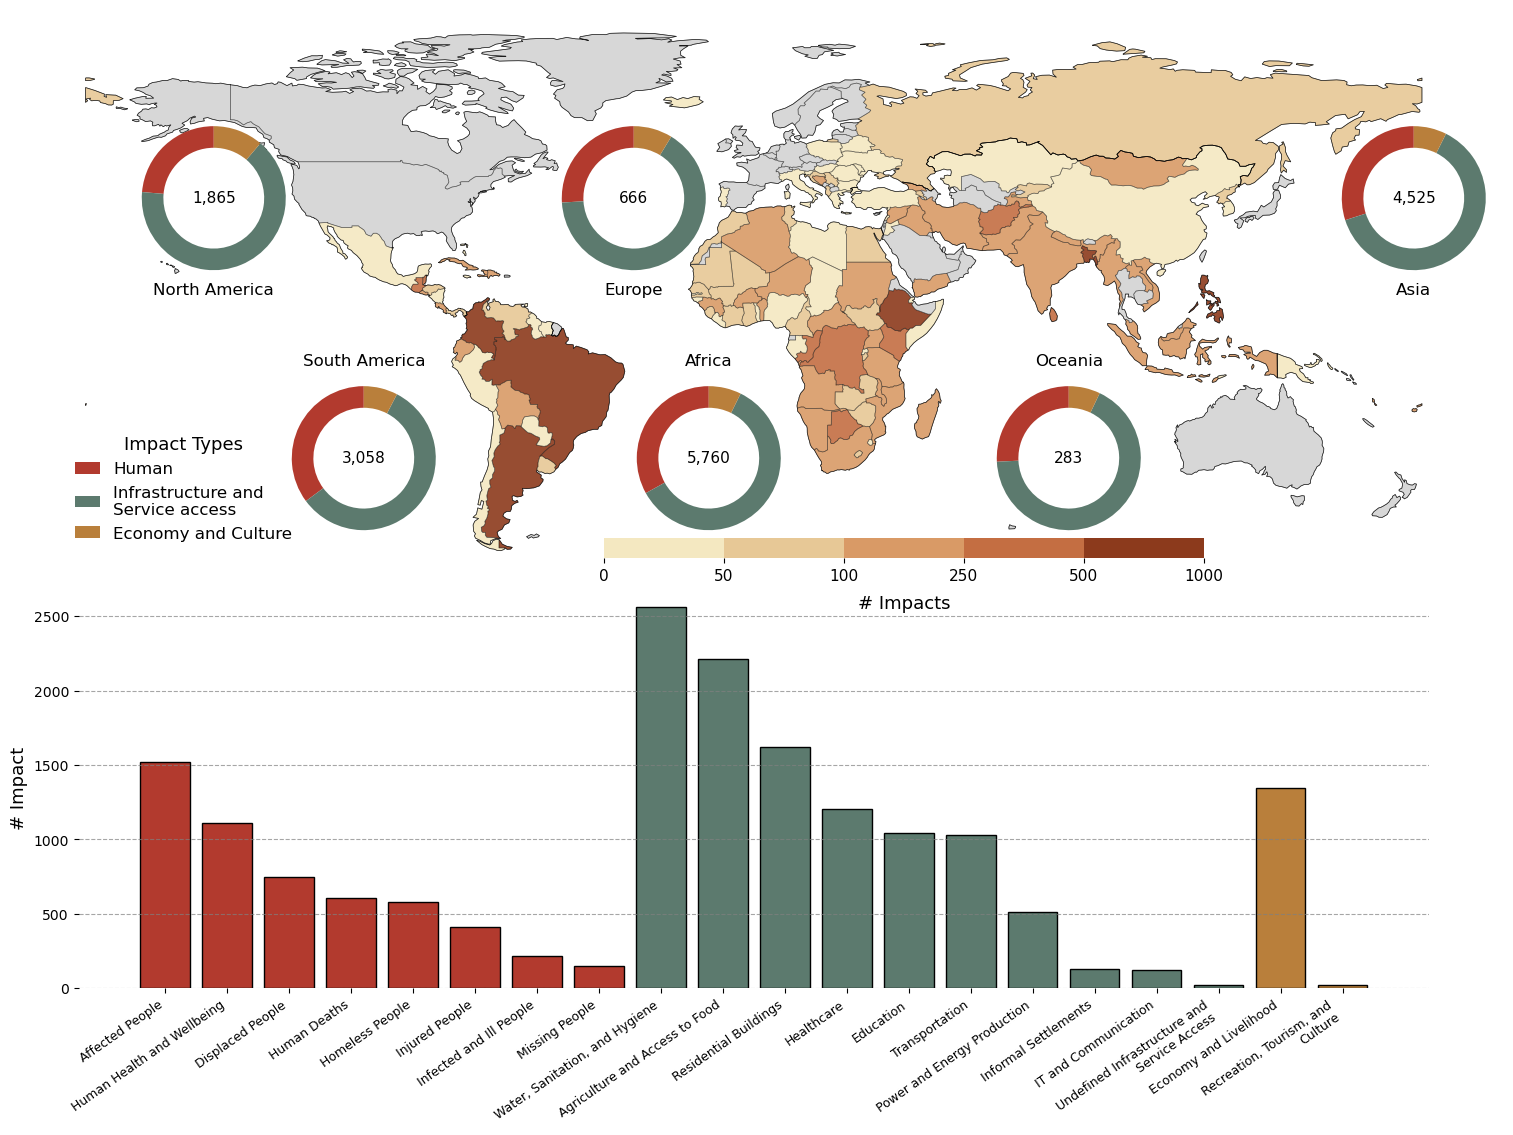

In [13]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

values = world_impact["impact_count"].dropna()

bounds = [0, 50, 100, 250, 500, 1000]

norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=13, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

# Add continents boundaries
continent_shapes.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.8)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.38, 0.24),
    'Asia': (0.85, 0.50),
    'Europe': (0.33, 0.50),
    'North America': (0.05, 0.50),
    'Oceania': (0.62, 0.24),
    'South America': (0.15, 0.24)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)
    
    # Impact data
    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_labels = impact_data.index
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, '#BBBBBB') for label in impact_labels]

    # Impact donut
    wedges_impact, _ = ax_donut.pie(impact_sizes, colors=impact_colors, startangle=90, wedgeprops=dict(width=0.3))
    
    # Add the total impact value 
    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0, 0, f'{total_impacts:,}',  # center text
        ha='center', va='center',
        fontsize=11, color='black'
    )

    #Make the donus
    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe'] :
        ax_donut.set_title(continent, fontsize=12, pad=2, y=-0.05)
    else : 
        ax_donut.set_title(continent, fontsize=12, pad=2, y=1)

# Add impact legend for impact types
wrapped_labels = {
    impact: '\n'.join(textwrap.wrap(impact, width=20))  # adjust width as needed
    for impact in impact_order if impact in impact_colormap
}

legend_ax = fig.add_axes([0.02, 0.1, 0.2, 0.4])
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements with wrapped labels
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order if impact in impact_colormap
]

# Add legend (allowing multiple columns if many elements)
legend_ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=12,
    title='Impact Types',
    title_fontsize=13,
    ncol=1,               # 🔹 split legend into 2 columns if long
    columnspacing=1.5,
    handlelength=1.5
)
legend_ax.set_axis_off()

# Add barplot of impact subtypes 
barplot_subtype_ax = fig.add_axes([0.05, -0.20, 0.9, 0.4])
barplot_subtype_ax.set_facecolor('white')
barplot_subtype_ax.patch.set_alpha(0)

impact_order = list(impact_colormap.keys())

all_reports_impactsubtype['impact_main_type'] = (
    pd.Categorical(
        all_reports_impactsubtype['impact_main_type'],
        categories=impact_order,
        ordered=True
    )
)

# Sort by: category (circle plot order) → subtype count (descending)
all_reports_impactsubtype_sorted = (
    all_reports_impactsubtype
    .sort_values(by=["impact_main_type", "impact_subtype_count"],
                 ascending=[True, False])
    .reset_index(drop=True)
)

barplot_subtype_ax.bar(
    x=all_reports_impactsubtype_sorted['impactSubtype'],
    height=all_reports_impactsubtype_sorted['impact_subtype_count'],
    color=all_reports_impactsubtype_sorted['color'],
    edgecolor='black'
)

# Rotate and add y labels
wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=30))  # creates multi-line if long
    for label in all_reports_impactsubtype_sorted['impactSubtype']
]
barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha='right')

# Optional: improve layout and readability
barplot_subtype_ax.tick_params(axis='x', labelsize=9)
for spine in barplot_subtype_ax.spines.values():
    spine.set_visible(False)
barplot_subtype_ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
barplot_subtype_ax.set_ylabel('# Impact', fontsize=13)

plt.tight_layout()

fig.savefig(path_save_fig / f"impact_map.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()